In [2]:
# Clona o repositório para o ambiente do Google Colab.
# Se o repositório já estiver clonado nesta sessão, não é necessário executar novamente.
import os

repositorio = "/content/grupo-01-projeto_supervisionado-II"

if not os.path.exists(repositorio):
    !git clone https://github.com/especializacao-ia-pucsp/grupo-01-projeto_supervisionado-II.git


Cloning into 'grupo-01-projeto_supervisionado-II'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 96 (delta 27), reused 41 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 5.26 MiB | 18.37 MiB/s, done.
Resolving deltas: 100% (27/27), done.


# 1. Preparação do ambiente

Esta etapa desenvolve o módulo de **Visão Computacional** do projeto. O objetivo é utilizar as imagens anexadas aos chamados como uma fonte adicional de informação para a classificação das categorias.

O fluxo desta etapa é:

1. carregar e inspecionar as imagens;
2. realizar o pré-processamento;
3. associar as imagens às categorias dos chamados;
4. construir uma CNN para classificação;
5. avaliar o desempenho e discutir as limitações do experimento.

Como o projeto possui uma abordagem multimodal, os resultados desta etapa serão posteriormente utilizados como referência para a integração com outras modalidades de dados.

In [3]:
from pathlib import Path

# Diretório raiz do projeto clonado no Google Colab.
raiz_projeto = Path("/content/grupo-01-projeto_supervisionado-II")


# 2. Carregamento e inspeção das imagens

Nesta etapa são carregadas as imagens disponíveis no projeto e verificadas suas características básicas, como quantidade, formato e dimensões.

### 2.1 — Definição do caminho das imagens

O diretório abaixo contém as imagens anexadas aos chamados que serão utilizadas no módulo de Visão Computacional.

In [4]:
caminho_imagens = raiz_projeto / "data" / "raw" / "images"

print("Pasta de imagens:", caminho_imagens)


Pasta de imagens: /content/grupo-01-projeto_supervisionado-II/data/raw/images


### 2.2 — Carregamento dos dados dos chamados

Além das imagens, precisamos consultar o dataset original para obter a relação entre `image_path` e `target_category`. Essa relação será usada posteriormente para criar os rótulos supervisionados da CNN.

O dataset é carregado explicitamente neste notebook para que esta etapa possa ser reproduzida sem depender de variáveis criadas em outro notebook.

In [5]:
import pandas as pd

caminho_dados = raiz_projeto / "data" / "raw" / "chamados.csv"

df_original = pd.read_csv(caminho_dados)

print("Formato do dataset:", df_original.shape)


Formato do dataset: (5000, 44)


2.3 — Listagem das imagens

In [6]:
import os

os.listdir(caminho_imagens)

['browser.png',
 'finance_report.png',
 'default_finance.png',
 'motherboard.png',
 'mouse.png',
 'hard_drive.png',
 'payroll.png',
 'default_hardware.png',
 'power_supply.png',
 'default_network.png',
 'recruitment.png',
 'cooler.png',
 'default_software.png',
 'email.png',
 'access_denied.png',
 'login.png',
 'vpn.png',
 'default_access.png',
 'default_hr.png',
 'hr_portal.png',
 'network.png',
 'server.png',
 'sap_erp.png',
 'keyboard.png',
 'monitor.png',
 'office.png']

2.4 — Visualização de uma imagem

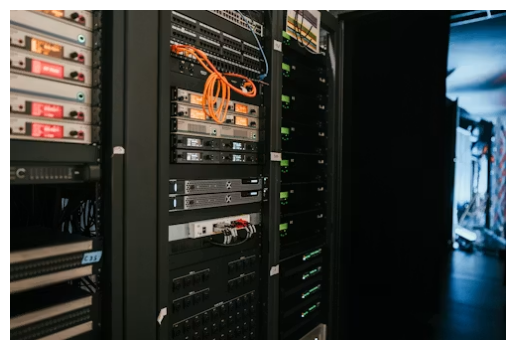

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

imagem = Image.open(f"{caminho_imagens}/server.png")

plt.imshow(imagem)
plt.axis("off")
plt.show()

2.5 — Verificação das dimensões das imagens

In [8]:
for arquivo in os.listdir(caminho_imagens):
    if arquivo.endswith(".png"):
        imagem = Image.open(os.path.join(caminho_imagens, arquivo))
        print(arquivo, imagem.size)

browser.png (500, 333)
finance_report.png (738, 414)
default_finance.png (500, 750)
motherboard.png (612, 408)
mouse.png (500, 335)
hard_drive.png (500, 334)
payroll.png (612, 408)
default_hardware.png (612, 407)
power_supply.png (500, 375)
default_network.png (500, 333)
recruitment.png (500, 333)
cooler.png (500, 750)
default_software.png (612, 344)
email.png (500, 333)
access_denied.png (612, 408)
login.png (500, 333)
vpn.png (500, 333)
default_access.png (191, 165)
default_hr.png (612, 408)
hr_portal.png (323, 619)
network.png (500, 342)
server.png (500, 333)
sap_erp.png (612, 344)
keyboard.png (500, 375)
monitor.png (500, 394)
office.png (500, 333)


# 3. Pré-processamento das imagens

As imagens possuem dimensões diferentes e precisam ser convertidas para um formato padronizado antes de serem utilizadas pela CNN. Nesta etapa também é construída a relação entre cada imagem e sua categoria.

### 3.1 — Redimensionamento das imagens

As imagens originais possuem diferentes dimensões. Como uma CNN recebe entradas com formato fixo, todas as imagens são redimensionadas para **224 × 224 pixels**, mantendo três canais de cor (RGB).

In [9]:
from PIL import Image
import os

imagens_redimensionadas = []

for arquivo in os.listdir(caminho_imagens):

    if arquivo.lower().endswith((".png", ".jpg", ".jpeg")):

        caminho = os.path.join(caminho_imagens, arquivo)

        imagem = Image.open(caminho)
        imagem = imagem.resize((224, 224))

        imagens_redimensionadas.append(imagem)

print("Imagens redimensionadas:", len(imagens_redimensionadas))

Imagens redimensionadas: 26


### 3.2 — Normalização dos pixels

Os valores dos pixels originalmente variam de **0 a 255**. Eles são divididos por 255 para colocá-los no intervalo **0 a 1**, facilitando o processamento numérico durante o treinamento da rede.

In [10]:
import numpy as np

imagens_normalizadas = []

for imagem in imagens_redimensionadas:

    imagem_array = np.array(imagem)

    imagem_normalizada = imagem_array / 255.0

    imagens_normalizadas.append(imagem_normalizada)

print("Quantidade de imagens:", len(imagens_normalizadas))
print("Valor mínimo:", imagens_normalizadas[0].min())
print("Valor máximo:", imagens_normalizadas[0].max())

Quantidade de imagens: 26
Valor mínimo: 0.058823529411764705
Valor máximo: 1.0


### 3.3 — Organização inicial das imagens

As imagens pré-processadas são convertidas para um array NumPy. Esta é uma organização inicial dos dados; posteriormente, serão selecionadas apenas as imagens que possuem uma associação consistente com uma única categoria.

In [11]:
X_imagens = np.array(imagens_normalizadas)

print("Formato dos dados:", X_imagens.shape)

Formato dos dados: (26, 224, 224, 3)


### 3.4 — Validação da associação entre imagem e categoria

Antes de treinar a CNN, é necessário verificar se cada imagem pode receber um rótulo único. Algumas imagens do dataset aparecem associadas a mais de uma categoria de chamado, o que impede uma associação direta entre imagem e classe para este experimento.

In [12]:
categorias_por_imagem = (
    df_original
    .groupby("image_path")["target_category"]
    .nunique()
)

print("Imagens com uma única categoria:",
      (categorias_por_imagem == 1).sum())

print("Imagens com mais de uma categoria:",
      (categorias_por_imagem > 1).sum())

Imagens com uma única categoria: 17
Imagens com mais de uma categoria: 9


In [13]:
categorias_multiplas = (
    df_original
    .groupby("image_path")["target_category"]
    .unique()
)

display(
    categorias_multiplas[
        categorias_multiplas.apply(len) > 1
    ]
)

,target_category
image_path,
images/access_denied.png,"[Acesso, Software]"
images/email.png,"[Software, RH, Rede, Acesso, Financeiro]"
images/finance_report.png,"[Financeiro, Software, RH, Acesso, Rede]"
images/hr_portal.png,"[RH, Acesso]"
images/login.png,"[Acesso, RH, Rede, Financeiro, Software]"
images/network.png,"[Rede, Hardware]"
images/payroll.png,"[RH, Acesso]"
images/recruitment.png,"[RH, Acesso]"
images/sap_erp.png,"[Software, Financeiro]"


### 3.5 — Distribuição das categorias por imagem

A tabela abaixo permite visualizar como as imagens estão distribuídas entre as categorias e identificar quais arquivos aparecem associados a mais de uma classe.

In [14]:
distribuicao_imagens = pd.crosstab(
    df_original["image_path"],
    df_original["target_category"]
)

display(distribuicao_imagens)

target_category,Acesso,Financeiro,Hardware,RH,Rede,Software
image_path,,,,,,
images/access_denied.png,167,0,0,0,0,4
images/browser.png,0,0,0,0,0,243
images/cooler.png,0,0,70,0,0,0
images/default_access.png,139,0,0,0,0,0
images/default_finance.png,0,18,0,0,0,0
images/default_hardware.png,0,0,207,0,0,0
images/default_hr.png,0,0,0,219,0,0
images/default_network.png,0,0,0,0,193,0
images/default_software.png,0,0,0,0,0,105


### 3.6 — Seleção das imagens com rótulo consistente

Para este primeiro experimento supervisionado, serão utilizadas somente as imagens associadas a **uma única categoria**. Essa escolha evita atribuir um rótulo arbitrário a imagens que aparecem em diferentes categorias.

In [15]:
imagens_consistentes = categorias_por_imagem[
    categorias_por_imagem == 1
].index

print("Imagens selecionadas:", len(imagens_consistentes))

display(imagens_consistentes)

Imagens selecionadas: 17


Index(['images/browser.png', 'images/cooler.png', 'images/default_access.png',
       'images/default_finance.png', 'images/default_hardware.png',
       'images/default_hr.png', 'images/default_network.png',
       'images/default_software.png', 'images/hard_drive.png',
       'images/keyboard.png', 'images/monitor.png', 'images/motherboard.png',
       'images/mouse.png', 'images/office.png', 'images/power_supply.png',
       'images/server.png', 'images/vpn.png'],
      dtype='object', name='image_path')

### 3.7 — Associação entre imagens e categorias

A partir das imagens selecionadas, é construída a tabela que relaciona cada arquivo de imagem ao seu respectivo `target_category`. Essa tabela será a base para a criação de `X` e `y` do modelo.

In [16]:
rotulos_imagens = (
    df_original[
        df_original["image_path"].isin(imagens_consistentes)
    ][["image_path", "target_category"]]
    .drop_duplicates()
)

display(rotulos_imagens)

,image_path,target_category
0,images/keyboard.png,Hardware
4,images/server.png,Rede
5,images/default_finance.png,Financeiro
8,images/power_supply.png,Hardware
15,images/motherboard.png,Hardware
16,images/default_network.png,Rede
17,images/default_hardware.png,Hardware
19,images/vpn.png,Rede
27,images/hard_drive.png,Hardware
42,images/default_software.png,Software


### 3.8 — Preparação do conjunto supervisionado

As imagens selecionadas são recuperadas pelo nome do arquivo e organizadas em um array com o formato esperado pela CNN: **número de imagens × altura × largura × canais**.

In [17]:
arquivos_processados = [
    arquivo for arquivo in os.listdir(caminho_imagens)
    if arquivo.lower().endswith((".png", ".jpg", ".jpeg"))
]

# Associa cada nome de arquivo diretamente à imagem normalizada.
mapa_imagens = {
    arquivo: imagem
    for arquivo, imagem in zip(arquivos_processados, imagens_normalizadas)
}

X_imagens = np.array([
    mapa_imagens[caminho.replace("images/", "")]
    for caminho in rotulos_imagens["image_path"]
])

print("Formato de X_imagens:", X_imagens.shape)

Formato de X_imagens: (17, 224, 224, 3)


### 3.9 — Criação dos rótulos

A coluna `target_category` é utilizada como variável-alvo. Cada imagem recebe a categoria correspondente definida na associação anterior.

In [18]:
y_imagens = rotulos_imagens["target_category"].values

print("Formato de y_imagens:", y_imagens.shape)
print(y_imagens)

Formato de y_imagens: (17,)
['Hardware' 'Rede' 'Financeiro' 'Hardware' 'Hardware' 'Rede' 'Hardware'
 'Rede' 'Hardware' 'Software' 'Software' 'Acesso' 'RH' 'Hardware'
 'Software' 'Hardware' 'Hardware']


### 3.10 — Codificação dos rótulos

As categorias textuais são convertidas em valores numéricos para que possam ser utilizadas pela rede neural. O `LabelEncoder` mantém o mapeamento entre os códigos e os nomes das categorias.

In [19]:
from sklearn.preprocessing import LabelEncoder

le_imagens = LabelEncoder()

y_imagens_codificado = le_imagens.fit_transform(y_imagens)

print("Categorias:", le_imagens.classes_)
print("Rótulos codificados:", y_imagens_codificado)

Categorias: ['Acesso' 'Financeiro' 'Hardware' 'RH' 'Rede' 'Software']
Rótulos codificados: [2 4 1 2 2 4 2 4 2 5 5 0 3 2 5 2 2]


### 3.11 — Divisão dos dados em treino e teste

Os dados são divididos em **70% para treinamento e 30% para teste**. Como existem apenas 17 imagens com rótulo consistente, não foi utilizada estratificação: algumas categorias possuem pouquíssimos exemplos, o que inviabilizaria uma divisão estratificada adequada.

In [20]:
from sklearn.model_selection import train_test_split

X_img_treino, X_img_teste, y_img_treino, y_img_teste = train_test_split(
    X_imagens,
    y_imagens_codificado,
    test_size=0.30,
    random_state=42
)

print("Treino:", X_img_treino.shape, y_img_treino.shape)
print("Teste:", X_img_teste.shape, y_img_teste.shape)

Treino: (11, 224, 224, 3) (11,)
Teste: (6, 224, 224, 3) (6,)


# 4. Construção da CNN

Nesta etapa é construída uma **Rede Neural Convolucional (CNN)** para classificar as imagens nas categorias dos chamados.

A arquitetura foi mantida simples devido à quantidade limitada de imagens disponíveis. O objetivo deste experimento é demonstrar o fluxo de classificação visual e avaliar se as imagens, isoladamente, apresentam informação suficiente para generalizar para novos exemplos.

### 4.1 — Importação das bibliotecas para a CNN

São utilizadas as bibliotecas do TensorFlow/Keras para construir e treinar a CNN, além das ferramentas de visualização e avaliação dos resultados.

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

### 4.2 — Construção da arquitetura da CNN

A arquitetura utiliza duas camadas convolucionais, cada uma seguida por uma camada de `MaxPooling`. Depois, as características extraídas são transformadas em um vetor com `Flatten`.

De forma simplificada:

**Imagem → Convolução → Pooling → Convolução → Pooling → Flatten → Classificação**

As primeiras camadas buscam características visuais locais, enquanto as camadas posteriores utilizam essas características para a classificação.

In [22]:
model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten()
])

### 4.3 — Camadas de classificação

Após a extração das características visuais, duas camadas densas realizam a classificação. A última camada possui **6 neurônios**, correspondentes às seis categorias presentes no conjunto selecionado, e utiliza `softmax` para produzir as probabilidades das classes.

In [23]:
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(6, activation='softmax'))

### 4.4 — Compilação do modelo

O modelo utiliza o otimizador **Adam**, a função de perda `sparse_categorical_crossentropy` e a métrica `accuracy`.

A função de perda compara a categoria real com a categoria prevista, enquanto a acurácia indica a proporção de classificações corretas.

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 4.5 — Treinamento da CNN

A CNN é treinada durante **20 épocas**. Uma parcela de 20% do conjunto de treinamento é utilizada internamente para validação durante o treinamento.

Como o conjunto possui apenas 11 imagens destinadas ao treinamento, a validação contém pouquíssimos exemplos. Portanto, os valores de validação devem ser interpretados com cautela.

In [25]:
historico = model.fit(
    X_img_treino,
    y_img_treino,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1250 - loss: 1.7557 - val_accuracy: 0.6667 - val_loss: 10.4469
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step - accuracy: 0.5000 - loss: 7.7115 - val_accuracy: 0.0000e+00 - val_loss: 14.0247
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step - accuracy: 0.3750 - loss: 2.0587 - val_accuracy: 0.3333 - val_loss: 8.0004
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8750 - loss: 0.5140 - val_accuracy: 0.6667 - val_loss: 7.1594
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8750 - loss: 0.7530 - val_accuracy: 0.3333 - val_loss: 6.2820
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8750 - loss: 0.3639 - val_accuracy: 0.3333 - val_loss: 6.1147
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0350 - val_accuracy: 0.0000e+00 - val_loss: 7.1805
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0347 - val_accuracy: 0.0000e+00 - val_loss: 7.5

### 4.6 — Curvas de treinamento

As curvas abaixo permitem comparar o comportamento da perda e da acurácia no treinamento e na validação. Elas ajudam a visualizar o possível overfitting observado durante o treinamento.

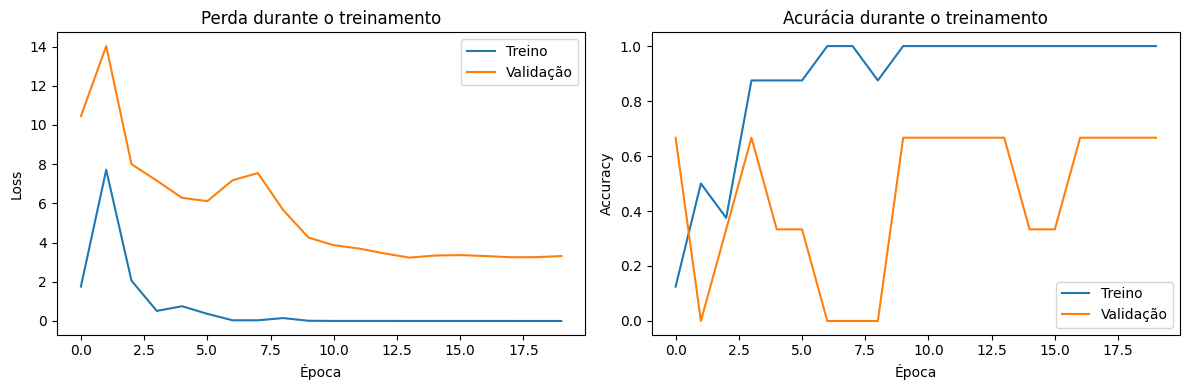

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico.history["loss"], label="Treino")
axes[0].plot(historico.history["val_loss"], label="Validação")
axes[0].set_title("Perda durante o treinamento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(historico.history["accuracy"], label="Treino")
axes[1].plot(historico.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia durante o treinamento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.7 — Avaliação no conjunto de teste

Após o treinamento, o modelo é avaliado em imagens que não participaram do treinamento. Essa etapa fornece uma estimativa de como a CNN se comporta diante de exemplos não utilizados para ajustar seus parâmetros.

In [27]:
resultado_teste = model.evaluate(
    X_img_teste,
    y_img_teste,
    verbose=1
)

print("Loss no teste:", resultado_teste[0])
print("Accuracy no teste:", resultado_teste[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5000 - loss: 7.0944
Loss no teste: 7.094404220581055
Accuracy no teste: 0.5


### 4.8 — Análise das previsões

As previsões são convertidas da saída probabilística da `softmax` para a classe com maior probabilidade. A comparação entre os rótulos reais e previstos permite identificar quais imagens foram classificadas corretamente.

In [28]:
y_pred_prob = model.predict(X_img_teste)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Real:   ", y_img_teste)
print("Predito: ", y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Real:    [2 4 4 2 0 5]
Predito:  [2 5 2 2 2 5]


### 4.9 — Matriz de confusão

A matriz de confusão compara as categorias reais com as categorias previstas pela CNN. Os valores na diagonal principal representam acertos; os valores fora da diagonal representam erros de classificação.

Real:    [2 4 4 2 0 5]
Predito: [2 5 2 2 2 5]


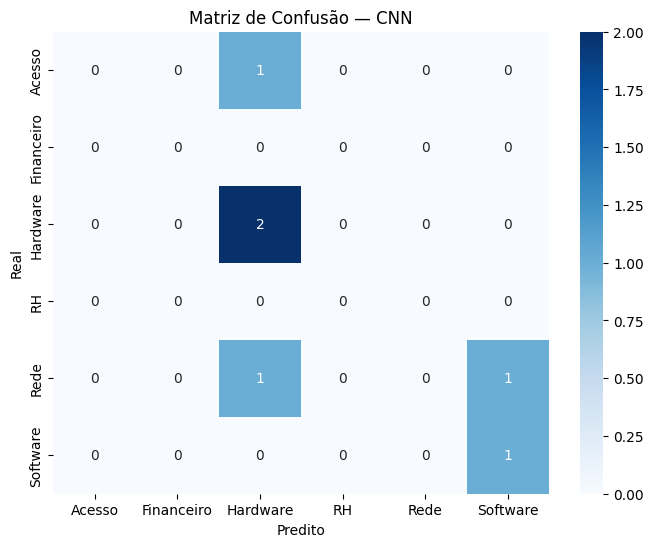

In [29]:
from sklearn.metrics import confusion_matrix

# Gerar as previsões do conjunto de teste
y_pred_prob = model.predict(X_img_teste, verbose=0)

# Transformar as probabilidades na classe prevista
y_pred = np.argmax(y_pred_prob, axis=1)

# Gerar a matriz de confusão
cm = confusion_matrix(
    y_img_teste,
    y_pred,
    labels=np.arange(len(le_imagens.classes_))
)

print("Real:   ", y_img_teste)
print("Predito:", y_pred)

# Visualização
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_imagens.classes_,
    yticklabels=le_imagens.classes_
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão — CNN')
plt.show()

### 4.10 — Discussão dos resultados

A CNN apresentou **100% de acurácia no conjunto de treinamento**, **66,7% na validação** e **33,3% no conjunto de teste**.

A diferença entre o desempenho no treinamento e no teste indica **overfitting**: o modelo conseguiu ajustar-se muito bem aos exemplos de treinamento, mas apresentou dificuldade para generalizar para imagens não utilizadas durante o treinamento.

A matriz de confusão também mostra uma concentração das previsões em algumas categorias, principalmente em **Hardware**. Isso indica dificuldade para distinguir determinadas classes.

Os resultados precisam ser interpretados considerando a quantidade reduzida de dados. Foram utilizadas apenas **17 imagens distintas com associação consistente entre imagem e categoria**, e o conjunto de teste contém apenas **6 imagens**. Assim, a acurácia de 33,3% corresponde a **2 acertos em 6 exemplos** e não deve ser tratada como uma estimativa robusta do desempenho de uma CNN em um conjunto maior.

Portanto, o experimento demonstra o funcionamento de uma CNN para classificação das evidências visuais, mas também evidencia uma limitação importante do conjunto de dados: há poucas imagens distintas para treinamento e algumas imagens disponíveis estavam associadas a mais de uma categoria.

O resultado reforça a proposta **multimodal** do projeto. As imagens podem contribuir como uma fonte adicional de informação, mas a classificação dos chamados deve ser analisada em conjunto com outras modalidades, como os dados textuais e demais características disponíveis.